Import modules, define network and apply transformations

In [1]:
import torch
from torchvision.datasets import Flowers102
import scipy
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms

class FlowersNetwork(nn.Module):
    def __init__(self, in_channels, out_features, activation_function = F.relu):
        super(FlowersNetwork, self).__init__()

        # Define convolutional layers
        self.conv1 = nn.Conv2d(in_channels=in_channels, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        # Define max pooling layer
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        # Define fully connected layers
        self.fc1 = nn.Linear(int(32*56*56), 512)
        self.fc2 = nn.Linear(512, out_features)

        self.activation_function = activation_function

    def forward(self, x):
        x = self.pool(self.activation_function(self.conv1(x)))
        x = self.pool(self.activation_function(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.activation_function(self.fc1(x))
        x = self.fc2(x)
        return x

# Set image dimensions
imageWidth = 224
imageHeight = 224

# Define batch size
batch_size = 32

# Calculate mean and standard deviation of the dataset for normalisation
flowersTransform_no_norm = transforms.Compose([
    transforms.Resize((imageWidth, imageHeight)),
    transforms.ToTensor()
])

flowersTrain_no_norm = Flowers102(root="./data", split="train", download=True, transform=flowersTransform_no_norm)
train_no_norm_loader = DataLoader(flowersTrain_no_norm, batch_size=batch_size, shuffle=False)

mean = 0.
std = 0.
total_samples = 0

for images, _ in train_no_norm_loader:
    batch_samples = images.size(0)
    images = images.view(batch_samples, images.size(1), -1)
    mean += images.mean(2).sum(0)
    std += images.std(2).sum(0)
    total_samples += batch_samples

mean /= total_samples
std /= total_samples

# Apply transformations to dataset
flowersTransform = transforms.Compose([
    transforms.Resize((imageWidth, imageHeight)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

flowersTrain = Flowers102(root = "./data", split = "train", download=True, transform = flowersTransform)
flowersTest = Flowers102(root = "./data", split = "test", download=True, transform = flowersTransform)

# Move model onto GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create DataLoaders for batch usage
train_loader = DataLoader(flowersTrain, batch_size=batch_size, shuffle=True)

imageChannels = 3 #R,G,B
imageSize = imageWidth*imageHeight*imageChannels


Initialise classifier, optimiser and loss function. Then train the model and output loss per epoch.

Epoch 1 - 4.659860327839851
Epoch 2 - 3.9928368255496025
Epoch 3 - 3.1447300985455513
Epoch 4 - 2.131178330630064
Epoch 5 - 1.2573173847049475
Epoch 6 - 0.6386272488161922
Epoch 7 - 0.34963745856657624
Epoch 8 - 0.17392735183238983
Epoch 9 - 0.07687894382979721
Epoch 10 - 0.042542620212771
Epoch 11 - 0.024506765534169972
Epoch 12 - 0.017551752360304818
Epoch 13 - 0.013351457891985774
Epoch 14 - 0.011122362280730158
Epoch 15 - 0.009247749694623053
Epoch 16 - 0.008054492675000802
Epoch 17 - 0.006961907958611846
Epoch 18 - 0.006186776539834682
Epoch 19 - 0.005541503735003062
Epoch 20 - 0.004867107272730209
Epoch 21 - 0.004396852484205738
Epoch 22 - 0.003998189698904753
Epoch 23 - 0.0036409849344636314
Epoch 24 - 0.0033226510931854136
Epoch 25 - 0.003065785720536951
Epoch 26 - 0.002835520459484542
Epoch 27 - 0.002640465918375412
Epoch 28 - 0.0024175344333343673
Epoch 29 - 0.002268796346470481
Epoch 30 - 0.002113562437443761
Epoch 31 - 0.001973252754396526
Epoch 32 - 0.001855904880358139
Ep

Text(0.5, 0, 'Epoch')

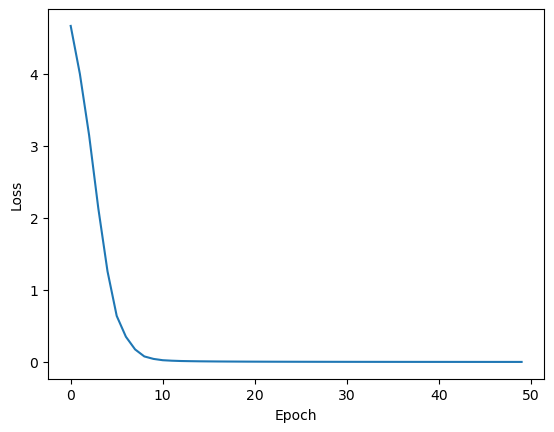

In [2]:
classifier = FlowersNetwork(in_channels = imageChannels, out_features = 102, activation_function = F.relu)

# Move model to GPU
classifier.to(device)

lossFunction = nn.CrossEntropyLoss()
optimiser = torch.optim.Adam(classifier.parameters(), lr=0.0001)

classifier.train()
epochs = 50
patience = 3 
losses = []
for i in range(epochs):
  epochLoss = 0.0
  for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)

    predictions = classifier.forward(images)

    loss = lossFunction(predictions, labels)
    epochLoss += loss.item()

    optimiser.zero_grad()
    loss.backward()
    optimiser.step()

  epochLoss /= len(train_loader)
  losses.append(epochLoss)
  print(f"Epoch {i+1} - {epochLoss}")

# Plot graph
plt.plot(range(len(losses)), losses)
plt.ylabel("Loss")
plt.xlabel("Epoch")

Calculate model accuracy

In [3]:
with torch.no_grad():
  classifier.eval()
  correct = 0
  total = 0
  test_loader = DataLoader(flowersTest, batch_size=1)
  for images, labels in test_loader:
        images = images.to(device)
        predictions = classifier.forward(images)
        _, predictedClass = torch.max(predictions, dim=1)
        
        total += 1
        if predictedClass.item() == labels.item():
            correct += 1
  accuracy = correct / total
  print(f"Model Accuracy: {accuracy}")

Model Accuracy: 0.17726459586924703


Model's accuracy (on my run): 17.7% - quite low, but much better than randomly picking.
CNN model is already much better than the linear model. The model would likely benefit from more convolutional layers.
Experimenting with kernel size, optimisers, activation functions and learning rate could also be beneficial.